In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import plotly.express as px


In [4]:
df = pd.read_csv('HR_comma_sep (1).csv')
df.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [5]:
df.drop(['last_evaluation', 'Work_accident', 'left', 'promotion_last_5years'], axis=1, inplace=True)
df.head()

,satisfaction_level,number_project,average_montly_hours,time_spend_company,Department,salary
0,0.38,2,157,3,sales,low
1,0.80,5,262,6,sales,medium
2,0.11,7,272,4,sales,medium
3,0.72,5,223,5,sales,low
4,0.37,2,159,3,sales,low


In [6]:
df.isnull().sum()

satisfaction_level      0
number_project          0
average_montly_hours    0
time_spend_company      0
Department              0
salary                  0
dtype: int64

In [7]:
import numpy as np

numerical_cols = ['satisfaction_level','number_project',
                  'average_montly_hours','time_spend_company']

for col in numerical_cols:
    
    data = df[col]

    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    
    
    upper = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower) | (data > upper)]

    print(f"\n Column: {col}")
    print(" lower fence :", lower)
    print("upper fence :", upper)
    print("Outliers:", len(outliers))

    if len(outliers) > 0:
        df[col] = [min(max(x, lower), upper) for x in data]
        print(" Winsorization Applied ")
    else:
        print(" No Outliers")


 Column: satisfaction_level
 lower fence : -0.12999999999999995
upper fence : 1.39
Outliers: 0
 No Outliers

 Column: number_project
 lower fence : 0.0
upper fence : 8.0
Outliers: 0
 No Outliers

 Column: average_montly_hours
 lower fence : 22.5
upper fence : 378.5
Outliers: 0
 No Outliers

 Column: time_spend_company
 lower fence : 1.5
upper fence : 5.5
Outliers: 1282
 Winsorization Applied 


In [8]:
# mapping the salary column
df['salary_maping'] = df['salary'].map({
    'low': 15000,
    'medium': 25000,
    'high': 50000
})
lable = LabelEncoder()
# labeling Department column
df['department_label '] = lable.fit_transform(df['Department'])
df.head(20)

,satisfaction_level,number_project,average_montly_hours,time_spend_company,Department,salary,salary_maping,department_label
0,0.38,2,157,3.0,sales,low,15000,7
1,0.80,5,262,5.5,sales,medium,25000,7
2,0.11,7,272,4.0,sales,medium,25000,7
3,0.72,5,223,5.0,sales,low,15000,7
4,0.37,2,159,3.0,sales,low,15000,7
5,0.41,2,153,3.0,sales,low,15000,7
6,0.10,6,247,4.0,sales,low,15000,7
7,0.92,5,259,5.0,sales,low,15000,7
8,0.89,5,224,5.0,sales,low,15000,7
9,0.42,2,142,3.0,sales,low,15000,7


In [9]:
bins=[0, 80, 150, 250, 350,400]
labels=['very low','low', 'normal', 'high', 'very high']
df['monthly_hours_bin']=pd.cut(df['average_montly_hours'], bins=bins, labels=labels)
df

,satisfaction_level,number_project,average_montly_hours,time_spend_company,Department,salary,salary_maping,department_label,monthly_hours_bin
0,0.38,2,157,3.0,sales,low,15000,7,normal
1,0.80,5,262,5.5,sales,medium,25000,7,high
2,0.11,7,272,4.0,sales,medium,25000,7,high
3,0.72,5,223,5.0,sales,low,15000,7,normal
4,0.37,2,159,3.0,sales,low,15000,7,normal
...,...,...,...,...,...,...,...,...,...
14994,0.40,2,151,3.0,support,low,15000,8,normal
14995,0.37,2,160,3.0,support,low,15000,8,normal
14996,0.37,2,143,3.0,support,low,15000,8,low
14997,0.11,6,280,4.0,support,low,15000,8,high


In [10]:
df['satisfaction_bin'] = pd.cut(df['satisfaction_level'], bins=3, labels=['Low', 'Medium', 'High'])
df.head(10)

,satisfaction_level,number_project,average_montly_hours,time_spend_company,Department,salary,salary_maping,department_label,monthly_hours_bin,satisfaction_bin
0,0.38,2,157,3.0,sales,low,15000,7,normal,Low
1,0.80,5,262,5.5,sales,medium,25000,7,high,High
2,0.11,7,272,4.0,sales,medium,25000,7,high,Low
3,0.72,5,223,5.0,sales,low,15000,7,normal,High
4,0.37,2,159,3.0,sales,low,15000,7,normal,Low
5,0.41,2,153,3.0,sales,low,15000,7,normal,Medium
6,0.10,6,247,4.0,sales,low,15000,7,normal,Low
7,0.92,5,259,5.0,sales,low,15000,7,high,High
8,0.89,5,224,5.0,sales,low,15000,7,normal,High
9,0.42,2,142,3.0,sales,low,15000,7,low,Medium


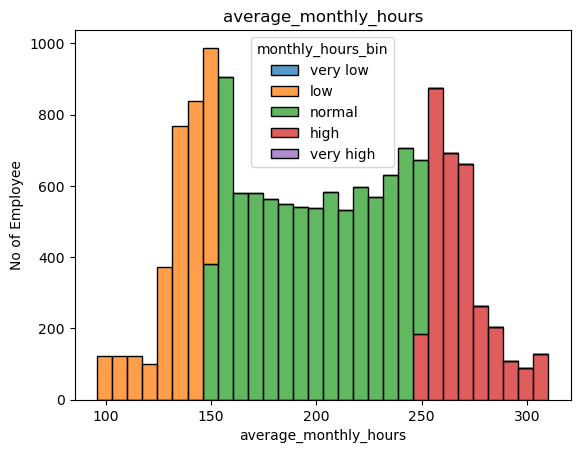

In [11]:
import seaborn as sns

plt.figure()
sns.histplot(data=df, x='average_montly_hours', hue='monthly_hours_bin', multiple='stack')

plt.title('average_monthly_hours')
plt.xlabel('average_monthly_hours')
plt.ylabel('No of Employee')
plt.show()

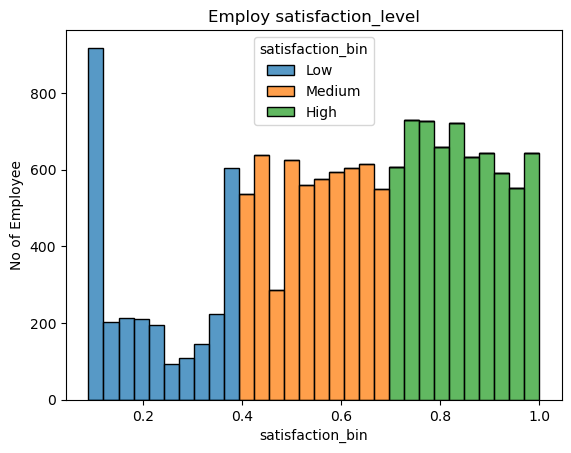

In [12]:

plt.figure()
sns.histplot(data=df, x='satisfaction_level', hue='satisfaction_bin', multiple='stack')

plt.title('Employ satisfaction_level')
plt.xlabel('satisfaction_bin')
plt.ylabel('No of Employee')
plt.show()

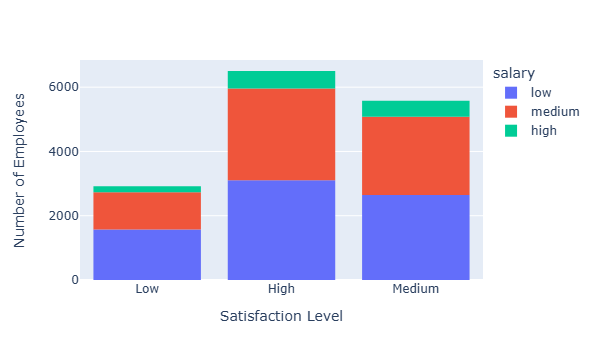

In [13]:
import plotly.express as px

fig = px.histogram(df, x='satisfaction_bin', color='salary')
fig.update_layout(
    xaxis_title="Satisfaction Level",
    yaxis_title="Number of Employees"
)
fig.show()

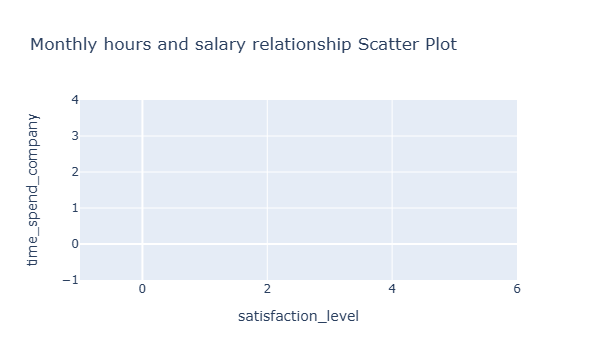

In [14]:
import plotly.express as px

fig = px.scatter(
    df, x="satisfaction_level", y="time_spend_company",
    color="Department", size="average_montly_hours",
    hover_data=["salary"],
    title="Monthly hours and salary relationship Scatter Plot"
)
fig.show()

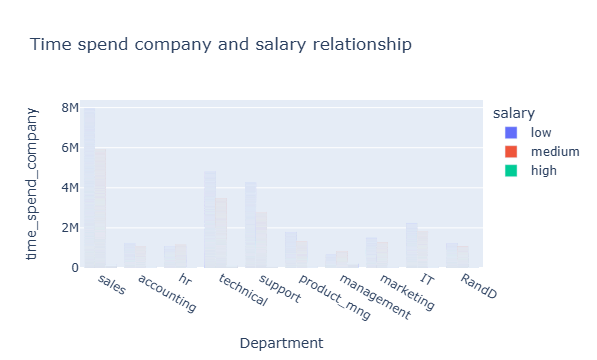

In [15]:
fig = px.bar(
    df,
    x="Department",
    y="time_spend_company",
    color="salary",
    barmode="group",
    hover_data=["monthly_hours_bin"],
    title="Time spend company and salary relationship")
fig.show()

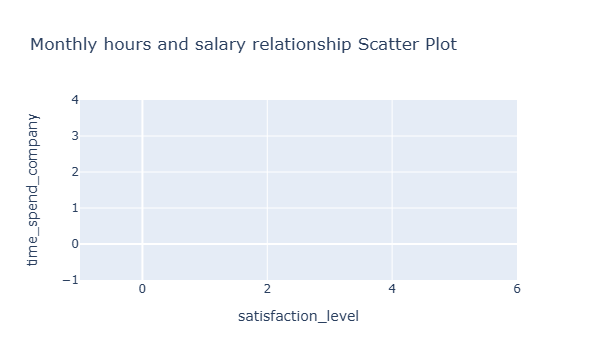

In [16]:
import plotly.express as px
fig = px.scatter(
    df, x="satisfaction_level", y="time_spend_company",
    color="Department", size="average_montly_hours",
    hover_data=["salary"],
    title="Monthly hours and salary relationship Scatter Plot"
)
fig.show()